# Notebook 05 — Feature Matrix + Modelos Tuneados (Experimentos 3T y 4T)

## Objetivo

Este notebook hace dos cosas, en orden:

1. Construye la `feature_matrix.csv` (técnicas + macro + sentiment, 14 features) que se usa en el resto del proyecto.
2. Entrena XGBoost y MLP con **hiperparámetros óptimos** encontrados mediante walk-forward expanding window + Bayesian search (Optuna TPE), y los guarda como `xgboost_tuned` / `mlp_tuned`.

| Experimento | Modelo         | Features                          | Tuning                        |
|-------------|----------------|-----------------------------------|-------------------------------|
| 3T          | XGBoost        | Técnicas + Macro + Sentiment (14) | Walk-forward Bayesian (Optuna) |
| 4T          | MLP            | Técnicas + Macro + Sentiment (14) | Walk-forward Bayesian (Optuna) |

**Por qué tunear antes del ablation study**: el notebook 06 (Ablation Study) compara Logistic Regression y XGBoost baseline (notebook 03, sin sentiment) contra XGBoost y MLP **ya tuneados** con sentiment. Si comparáramos contra versiones sin tunear, la comparación estaría sesgada a favor del sentiment/deep learning por hiperparámetros subóptimos, no por el aporte real del componente. Por eso los modelos tuneados se entrenan y guardan acá, antes del ablation.

**Output**: `data/processed/feature_matrix.csv`, `models/xgboost_tuned.pkl`, `models/mlp_tuned.pkl`.

**Split**: idéntico al resto del proyecto — Train 2008–2023 / Val 2024 / Test 2025.

In [2]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

from src import data_loader, features, sentiment, models, utils, hyperparameters

utils.set_plot_style()

RAW_DIR       = "../data/raw"
PROCESSED_DIR = "../data/processed"
MODELS_DIR    = "../models"
CACHE_PATH    = f"{PROCESSED_DIR}/sentiment_cache.csv"

FEATURE_COLS = [
    "RSI_14", "MACD", "BB_position", "return_1d", "return_5d", "volume_change",
    "vix", "t10y2y", "fedfunds", "cpi", "unrate",
    "sentiment_mean", "sentiment_std", "news_count"
]

## Construcción de la feature matrix con sentiment

Cargamos el dataset base (`sp500_features.csv`) y lo enriquecemos con el sentiment diario agregado y shifteado 1 día (notebook 04). El resultado es la `feature_matrix.csv` con las 14 features finales + la variable objetivo.

Los días sin cobertura de noticias (feriados, fines de semana donde se publicaron noticias pero el mercado no abrió, o días muy tempranos con poca cobertura) reciben `sentiment_mean=0`, `sentiment_std=0` y `news_count=0` — lo que representa neutralidad de información.

In [3]:
# Cargar datos base
sp500_features_df = pd.read_csv(f"{PROCESSED_DIR}/sp500_features.csv",
                                index_col=0, parse_dates=True)

# Cargar y agregar sentiment
news = data_loader.load_news(RAW_DIR)
raw_sent = sentiment.load_or_run_finbert(news, CACHE_PATH)
sentiment_diario = sentiment.aggregate_daily_sentiment(raw_sent)

# Construir feature matrix completa
df = features.build_feature_matrix(
    sp500_features_df,
    sentiment=sentiment_diario,
    include_sentiment=True,
    save_path=f"{PROCESSED_DIR}/feature_matrix.csv",
)

print(f"\nFeature matrix: {df.shape}")
print(f"Cobertura de sentiment: {(df['news_count'] > 0).mean()*100:.1f}% de los días")
df[FEATURE_COLS].describe()

[sentiment] Cache incompleto (19,127/27,212 filas). Re-corriendo FinBERT.
[sentiment] Corriendo FinBERT sobre 27,212 titulares...
[sentiment] MPS no disponible, usando CPU.
[sentiment] Cargando ProsusAI/finbert en device='cpu'...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\pepob\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pepob\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs

[sentiment] Cache guardado en ../data/processed/sentiment_cache.csv.
[features] feature_matrix guardada en ../data/processed/feature_matrix.csv (4,491 filas).

Feature matrix: (4491, 20)
Cobertura de sentiment: 86.9% de los días


,RSI_14,MACD,BB_position,return_1d,return_5d,volume_change,vix,t10y2y,fedfunds,cpi,unrate,sentiment_mean,sentiment_std,news_count
count,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000,4491.000000
mean,55.167848,8.417637,0.593954,0.000437,0.002133,0.017051,19.907963,1.096774,1.352474,252.916671,5.928524,-0.066020,0.304703,5.425072
std,11.322411,32.963524,0.316448,0.012628,0.025120,0.202850,8.965803,0.964722,1.743574,32.623247,2.253823,0.268306,0.283741,6.171266
min,16.457584,-237.020227,-0.442345,-0.119841,-0.183401,-1.000000,9.140000,-1.080000,0.050000,211.398000,3.400000,-0.975366,0.000000,0.000000
25%,47.045804,-4.120670,0.362835,-0.004094,-0.008512,-0.077337,14.050000,0.300000,0.110000,228.807000,4.000000,-0.191990,0.000000,1.000000
50%,56.512040,10.603627,0.682747,0.000721,0.004007,-0.003180,17.440000,1.110000,0.210000,242.026000,5.100000,0.000000,0.364269,3.000000
75%,63.741188,22.605634,0.844446,0.005867,0.014960,0.086105,22.715000,1.825000,2.130000,268.383000,7.800000,0.000000,0.543774,6.000000
max,86.686650,121.081850,1.270722,0.115800,0.191112,3.234605,82.690000,2.910000,5.330000,325.063000,14.800000,0.950584,1.308031,55.000000


## Split temporal y escalado

Mismo split que en el resto del proyecto. El scaler se fitea solo sobre el train set.

| Conjunto | Período              |
|----------|----------------------|
| Train    | 2008–2023 (16 años)  |
| Val      | 2024 (1 año)         |
| Test     | 2025 (1 año)         |

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = models.temporal_split(
    df, features=FEATURE_COLS, target="target"
)
X_train_s, X_val_s, X_test_s, scaler = models.scale_features(X_train, X_val, X_test)

[models] Split temporal:
  train: 3,997 muestras (2008-02-13 → 2023-12-29)
  val:   252 muestras (2024-01-02 → 2024-12-31)
  test:  242 muestras (2025-01-02 → 2025-12-18)


## Experimento 3T: XGBoost — Walk-Forward Bayesian Search

Buscamos los mejores hiperparámetros para XGBoost usando walk-forward expanding window sobre los años 2020–2024, optimizando AUC-ROC promedio.

| Hiperparámetro    | Rango de búsqueda       |
|-------------------|-------------------------|
| `max_depth`       | [3, 6]                  |
| `learning_rate`   | [0.01, 0.20] log        |
| `subsample`       | [0.6, 1.0]              |
| `colsample_bytree`| [0.6, 1.0]              |
| `min_child_weight`| [1, 7]                  |
| `reg_alpha`       | [0.0, 2.0]              |
| `reg_lambda`      | [0.5, 3.0]              |
| `gamma`           | [0.0, 2.0]              |

In [5]:
best_params_xgb, study_xgb = hyperparameters.walk_forward_bayesian_search(
    df,
    features=FEATURE_COLS,
    target="target",
    n_trials=50,
)

Best trial: 49. Best value: 0.567347: 100%|██████████| 50/50 [00:13<00:00,  3.79it/s]


[hyperparameters] Walk-forward Bayesian search — 50 trials, 5 folds
  Mejor AUC-CV promedio: 0.5673
  Mejores parámetros:
    max_depth             : 4
    learning_rate         : 0.17301
    subsample             : 0.76917
    colsample_bytree      : 0.71879
    min_child_weight      : 1
    reg_alpha             : 0.26007
    reg_lambda            : 0.9991
    gamma                 : 0.88869


In [6]:
xgb_tuned = hyperparameters.train_xgboost_tuned(
    X_train_s, y_train, X_val_s, y_val, best_params_xgb
)

metricas_xgb = {}
for nombre, X, y in [("train", X_train_s, y_train), ("val", X_val_s, y_val), ("test", X_test_s, y_test)]:
    metricas_xgb[nombre] = models.evaluate_model(xgb_tuned, X, y, nombre)

models.save_model(xgb_tuned, scaler, "xgboost_tuned", MODELS_DIR)

[hyperparameters] XGBoost tuneado. Mejor ronda: 8

── TRAIN ──
  accuracy    : 0.6087
  f1          : 0.6091
  roc_auc     : 0.6567
  precision   : 0.6099
  recall      : 0.6087

── VAL ──
  accuracy    : 0.5556
  f1          : 0.5479
  roc_auc     : 0.5952
  precision   : 0.5948
  recall      : 0.5556

── TEST ──
  accuracy    : 0.4628
  f1          : 0.4502
  roc_auc     : 0.4942
  precision   : 0.5034
  recall      : 0.4628
[models] xgboost_tuned guardado en ../models/


## Experimento 4T: MLP — Walk-Forward Bayesian Search

Buscamos los mejores hiperparámetros para MLP usando walk-forward expanding window sobre los años 2020–2024, optimizando AUC-ROC promedio.

| Hiperparámetro       | Rango de búsqueda                              |
|----------------------|------------------------------------------------|
| `hidden_layer_sizes` | [(64,), (128,64), (256,128), (256,128,64)]     |
| `learning_rate_init` | [1e-4, 1e-2] log                               |
| `alpha` (L2)         | [1e-5, 1e-1] log                               |
| `activation`         | ['relu', 'tanh']                               |

El scaler se fitea dentro de cada fold para evitar data leakage en la normalización.

In [7]:
best_params_mlp, study_mlp = hyperparameters.walk_forward_bayesian_search_mlp(
    df,
    features=FEATURE_COLS,
    target="target",
    n_trials=50,
)

  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\pepob\miniconda3\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64,) which is of type tuple.
  optuna_warn(message)
c:\Users\pepob\miniconda3\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128, 64) which is of type tuple.
  optuna_warn(message)
c:\Users\pepob\miniconda3\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (256, 128) which is of type tuple.
  optuna_warn(message)
c:\Users\pepob\miniconda3\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, boo


[hyperparameters] Walk-forward Bayesian search MLP — 50 trials, 5 folds
  Mejor AUC-CV promedio: 0.5636
  Mejores parámetros:
    hidden_layer_sizes    : (64,)
    activation            : tanh
    learning_rate_init    : 0.00984
    alpha                 : 0.0055


In [8]:
mlp_tuned = hyperparameters.train_mlp_tuned(X_train_s, y_train, best_params_mlp)

metricas_mlp = {}
for nombre, X, y in [("train", X_train_s, y_train), ("val", X_val_s, y_val), ("test", X_test_s, y_test)]:
    metricas_mlp[nombre] = models.evaluate_model(mlp_tuned, X, y, nombre)

models.save_model(mlp_tuned, scaler, "mlp_tuned", MODELS_DIR)

[hyperparameters] MLP tuneado. Épocas: 17

── TRAIN ──
  accuracy    : 0.5514
  f1          : 0.5015
  roc_auc     : 0.5449
  precision   : 0.5432
  recall      : 0.5514

── VAL ──
  accuracy    : 0.5476
  f1          : 0.4477
  roc_auc     : 0.5736
  precision   : 0.4841
  recall      : 0.5476

── TEST ──
  accuracy    : 0.5496
  f1          : 0.4922
  roc_auc     : 0.5006
  precision   : 0.5044
  recall      : 0.5496
[models] mlp_tuned guardado en ../models/


## Comparación: XGBoost Tuned vs MLP Tuned

Comparamos los dos modelos tuneados. Métricas principales: AUC-ROC (métrica de ranking, insensible al desbalance) y F1-score.

In [9]:
filas = [
    {"Modelo": "XGBoost Tuned", "Split": s, **{k: v for k, v in m.items() if k != "split"}}
    for s, m in metricas_xgb.items()
]

if metricas_mlp is not None:
    filas += [
        {"Modelo": "MLP Tuned", "Split": s, **{k: v for k, v in m.items() if k != "split"}}
        for s, m in metricas_mlp.items()
    ]

tabla = pd.DataFrame(filas)
print("Comparación de modelos tuneados:")
display(tabla.set_index(["Modelo", "Split"]))

Comparación de modelos tuneados:


accuracy      f1  roc_auc  precision  recall
Modelo        Split                                              
XGBoost Tuned train    0.6087  0.6091   0.6567     0.6099  0.6087
              val      0.5556  0.5479   0.5952     0.5948  0.5556
              test     0.4628  0.4502   0.4942     0.5034  0.4628
MLP Tuned     train    0.5514  0.5015   0.5449     0.5432  0.5514
              val      0.5476  0.4477   0.5736     0.4841  0.5476
              test     0.5496  0.4922   0.5006     0.5044  0.5496

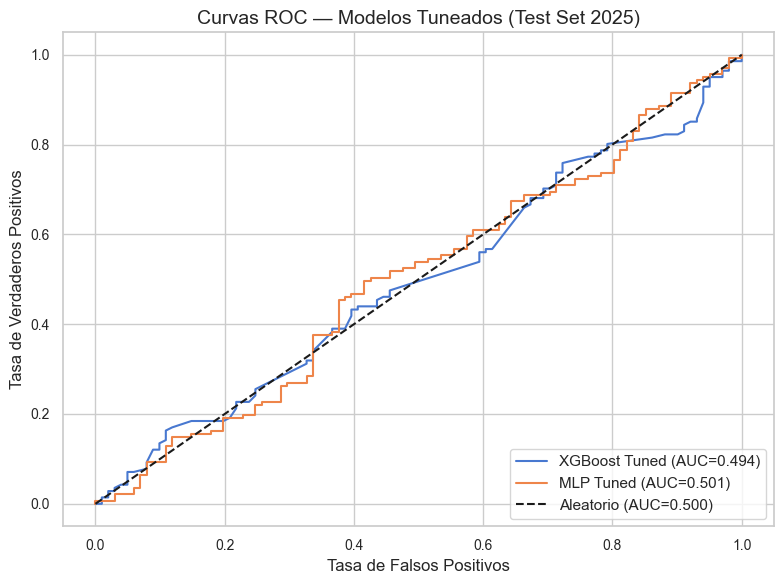

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

modelos_roc = [("XGBoost Tuned", xgb_tuned, X_test_s, y_test)]
if mlp_tuned is not None:
    modelos_roc.append(("MLP Tuned", mlp_tuned, X_test_s, y_test))

for label, modelo, X, y in modelos_roc:
    y_score = modelo.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_score)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{label} (AUC={roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Aleatorio (AUC=0.500)")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC — Modelos Tuneados (Test Set 2025)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()